# Task 1 — Dataset Tahlili va EDA

Dataset: svetafor rasmlari (`rasmlar/`), qolda YOLO format qilindi.
Classes: **0 = kamar_bor**, **1 = kamar_yoq**.

All numbers and figures below are computed by `eda_lib.py` so the README, the figures,
and this notebook never disagree. Figures are saved into `figures/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # so `task1_eda` is importable

import matplotlib.pyplot as plt
import seaborn as sns
from task1_eda.eda_lib import build_box_table, summary, CLASS_NAMES

sns.set_theme(style="whitegrid")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

df = build_box_table()
s = summary(df)
s

{'n_frames': 352,
 'n_empty_frames': 6,
 'n_boxes': 453,
 'kamar_bor': 97,
 'kamar_yoq': 356,
 'imbalance_ratio': 3.67,
 'boxes_per_frame_mean': 1.31,
 'boxes_per_frame_max': 6,
 'pct_night_frames': 96.9}

## 1.1.1 — Per-class box counts + bar chart

The PDF asks for per-class image counts; because this is a multi-object dataset (a frame
can hold several drivers of different classes) we count **boxes**, not images.

Frames:            352
Empty frames:      6
Boxes total:       453
kamar_bor   :   97 (21.4%)
kamar_yoq   :  356 (78.6%)
Imbalance (yoq:bor): 3.67 : 1


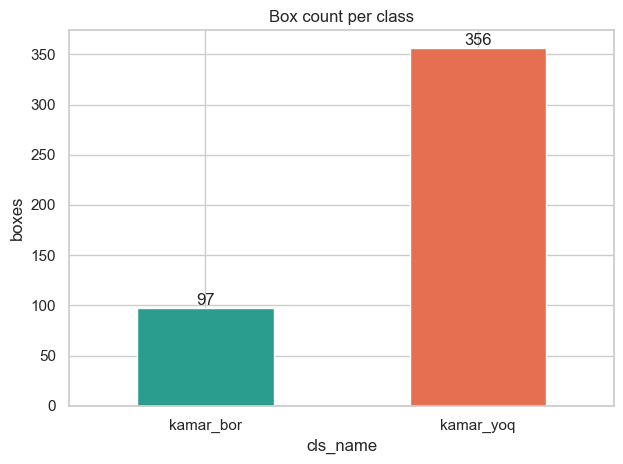

In [2]:
boxes = df[df.cls >= 0]
counts = boxes.cls_name.value_counts().reindex(CLASS_NAMES)
total = int(counts.sum())

print(f"Frames:            {s['n_frames']}")
print(f"Empty frames:      {s['n_empty_frames']}")
print(f"Boxes total:       {total}")
for name in CLASS_NAMES:
    c = int(counts[name]); print(f"{name:12s}: {c:4d} ({c/total:.1%})")
print(f"Imbalance (yoq:bor): {s['imbalance_ratio']} : 1")

ax = counts.plot(kind="bar", color=["#2a9d8f", "#e76f51"], rot=0)
ax.set_title("Box count per class"); ax.set_ylabel("boxes")
for i, v in enumerate(counts):
    ax.text(i, v + 3, str(int(v)), ha="center")
plt.tight_layout(); plt.savefig(FIG / "class_counts.png", dpi=120); plt.show()

## 1.1.2 — Class imbalance

Imbalance ratio is **~3.7 : 1** (kamar_yoq : kamar_bor). Mitigation plan documented in
the README: class weighting in YOLO, plus minority augmentation + weighted sampling for
the Stage-2 classifier; threshold chosen by Youden-J, not 0.5.

Boxes per frame: mean=1.31, max=6


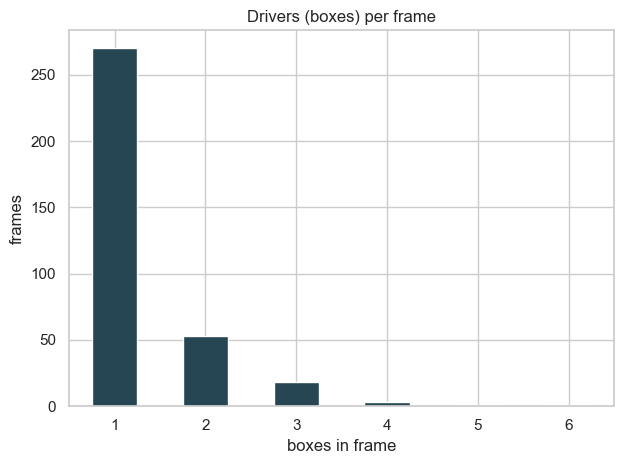

In [3]:
per_frame = boxes.groupby("stem").size()
print(f"Boxes per frame: mean={s['boxes_per_frame_mean']}, max={s['boxes_per_frame_max']}")
ax = per_frame.value_counts().sort_index().plot(kind="bar", color="#264653", rot=0)
ax.set_title("Drivers (boxes) per frame"); ax.set_xlabel("boxes in frame"); ax.set_ylabel("frames")
plt.tight_layout(); plt.savefig(FIG / "boxes_per_frame.png", dpi=120); plt.show()

## 1.1.3 — Bounding-box size scatter

Normalised width vs height per box, coloured by class. Tells us how small the driver
region is in the frame (drives the YOLOv8n-vs-s choice and `imgsz`).

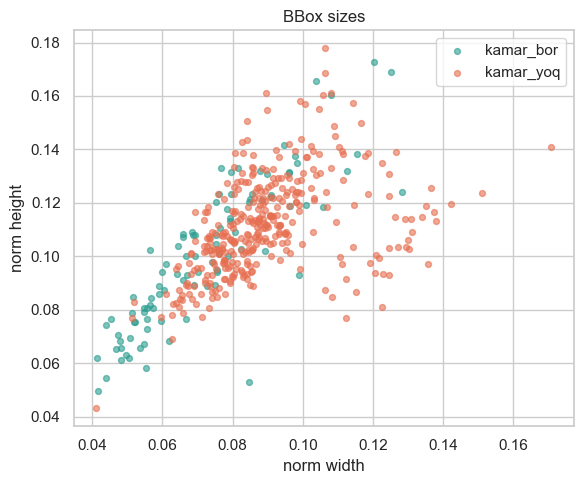

              w         h      area
count  453.0000  453.0000  453.0000
mean     0.0859    0.1088    0.0096
std      0.0194    0.0211    0.0034
min      0.0413    0.0431    0.0018
25%      0.0745    0.0952    0.0075
50%      0.0845    0.1081    0.0094
75%      0.0952    0.1222    0.0115
max      0.1708    0.1778    0.0241


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, color in zip(CLASS_NAMES, ["#2a9d8f", "#e76f51"]):
    sub = boxes[boxes.cls_name == name]
    ax.scatter(sub.w, sub.h, s=18, alpha=0.6, label=name, color=color)
ax.set_xlabel("norm width"); ax.set_ylabel("norm height"); ax.set_title("BBox sizes")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "bbox_scatter.png", dpi=120); plt.show()
print(boxes[["w", "h", "area"]].describe().round(4))

## 1.1.4 — Day vs night (colour vs IR) and brightness

**~97 % of frames are grayscale/IR (night).** The model is therefore learning almost
entirely on IR imagery — a key hard case (see README): daytime colour generalisation is
barely represented (only ~11 frames).

Night/IR frames: 341  (96.9%)
Day/colour frames: 11


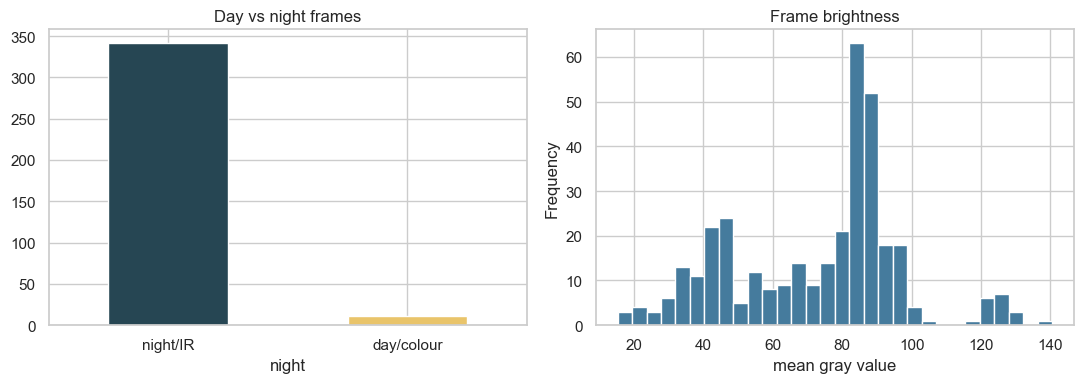

In [5]:
frame_night = df.groupby("stem").night.first()
print(f"Night/IR frames: {int(frame_night.sum())}  ({s['pct_night_frames']}%)")
print(f"Day/colour frames: {int((~frame_night).sum())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
frame_night.map({True: "night/IR", False: "day/colour"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#264653", "#e9c46a"], rot=0)
axes[0].set_title("Day vs night frames")
df.groupby("stem").brightness.first().plot(kind="hist", bins=30, ax=axes[1], color="#457b9d")
axes[1].set_title("Frame brightness"); axes[1].set_xlabel("mean gray value")
plt.tight_layout(); plt.savefig(FIG / "day_night_brightness.png", dpi=120); plt.show()

## 1.2 — Problem report (for README)

**Imbalance**: ~3.7:1 (kamar_yoq:kamar_bor); val set has only ~18 kamar_bor crops, so
ROC-AUC on the classifier will be noisy — reported honestly.

**Hard cases that can mislead the model:**
- ~97% IR/grayscale — almost no daytime colour training signal.
- Driver face often blacked-out (privacy mask) — belt cue must come from the torso/strap.
- Belt is thin and low-contrast against dark clothing, especially in IR.
- Multiple drivers per frame (up to 6) including passengers — only the driver is labelled.
- Windshield glare / reflections hide the strap.
- Small driver region inside a large 4096×2480 frame → favours higher imgsz / YOLOv8s.